In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
df = pd.read_csv("breast_cancer_data.csv")

In [13]:
print("First 5 Rows:")
print(df.head())



First 5 Rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_wor

In [4]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(569, 33)


In [5]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')


In [6]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_s

In [7]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064 

In [8]:
print("\nNull Values:")
print(df.isnull().sum())


Null Values:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst  

In [9]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())



Duplicate Rows:
0


In [10]:
df.drop_duplicates(inplace=True)


In [14]:
# Drop column if completely empty
if "Unnamed: 32" in df.columns:
    df.drop(columns=["Unnamed: 32"], inplace=True)

# Fill remaining null values if any
df.fillna(df.median(numeric_only=True), inplace=True)


In [15]:
print(df.isnull().sum())

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [16]:
if "id" in df.columns:
    df.drop(columns=["id"], inplace=True)


In [17]:
le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])
# B -> 0, M -> 1

In [18]:
print("\nClass Distribution:")
print(df["diagnosis"].value_counts())



Class Distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


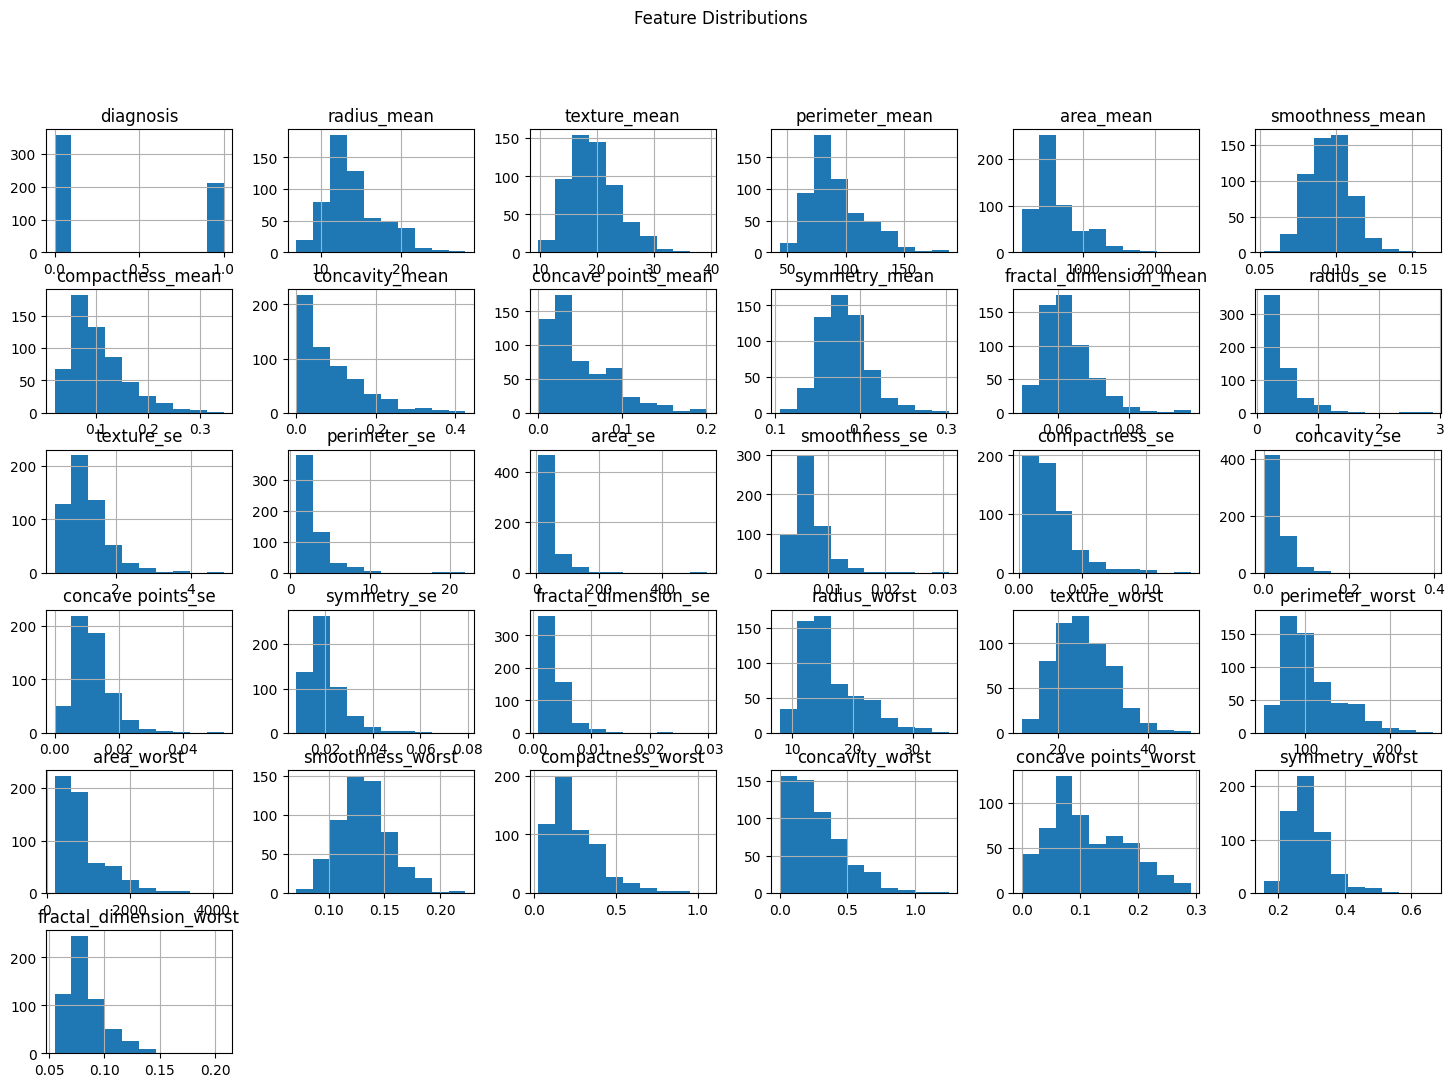

In [19]:
# Data Distribution
df.hist(figsize=(18, 12))
plt.suptitle("Feature Distributions")
plt.show()

C:\Users\saini\AppData\Local\Temp\ipykernel_15108\3876017300.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="diagnosis", data=df, palette = ["green","red"])


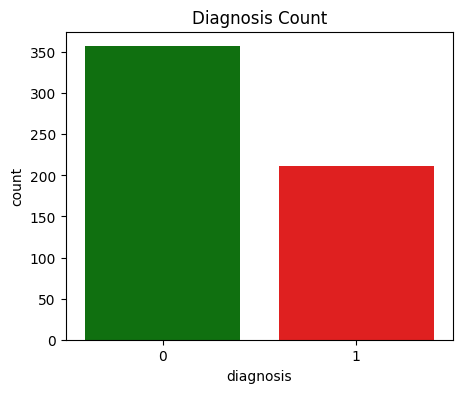

In [21]:
# Countplot

plt.figure(figsize=(5,4))
sns.countplot(x="diagnosis", data=df, palette = ["green","red"])
plt.title("Diagnosis Count")
plt.show()

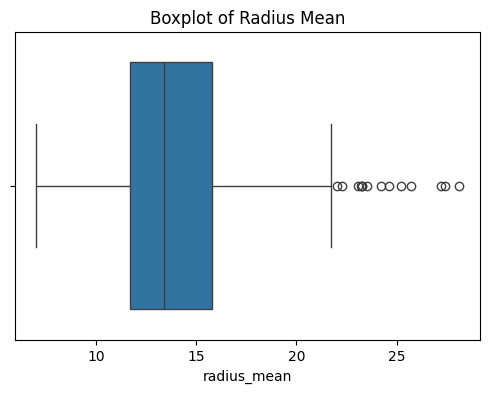

In [22]:
# Boxplot

plt.figure(figsize=(6,4))
sns.boxplot(x=df["radius_mean"])
plt.title("Boxplot of Radius Mean")
plt.show()


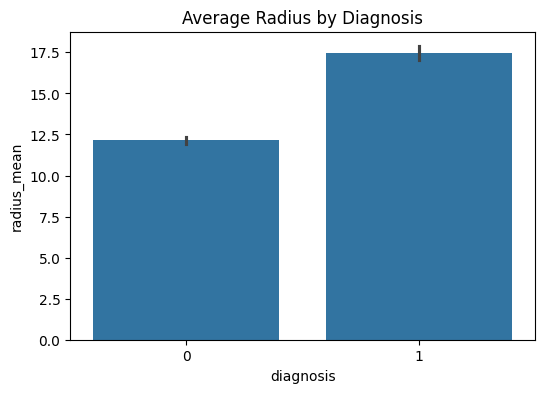

In [23]:
# Barplot

plt.figure(figsize=(6,4))
sns.barplot(x="diagnosis", y="radius_mean", data=df)
plt.title("Average Radius by Diagnosis")
plt.show()

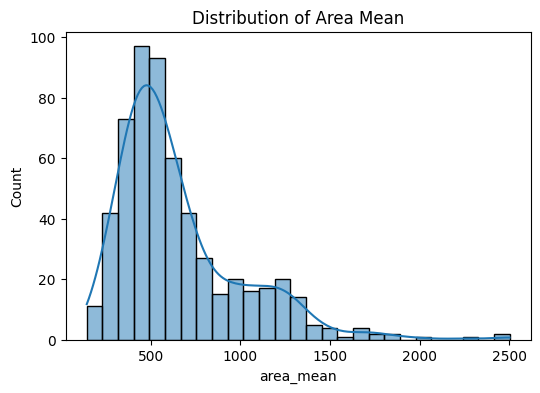

In [24]:
# Histplot

plt.figure(figsize=(6,4))
sns.histplot(df["area_mean"], kde=True)
plt.title("Distribution of Area Mean")
plt.show()

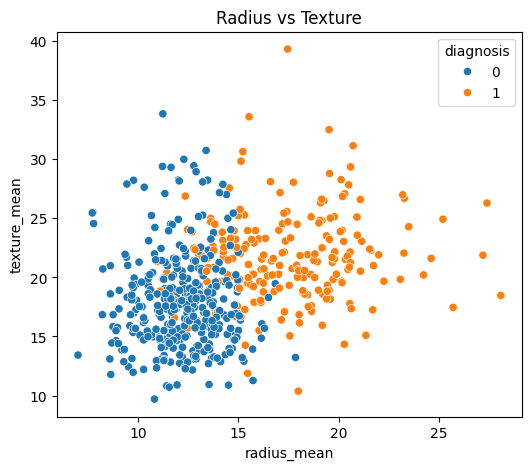

In [25]:
# Scatterplot

plt.figure(figsize=(6,5))
sns.scatterplot(
    x="radius_mean",
    y="texture_mean",
    hue="diagnosis",
    data=df
)
plt.title("Radius vs Texture")
plt.show()

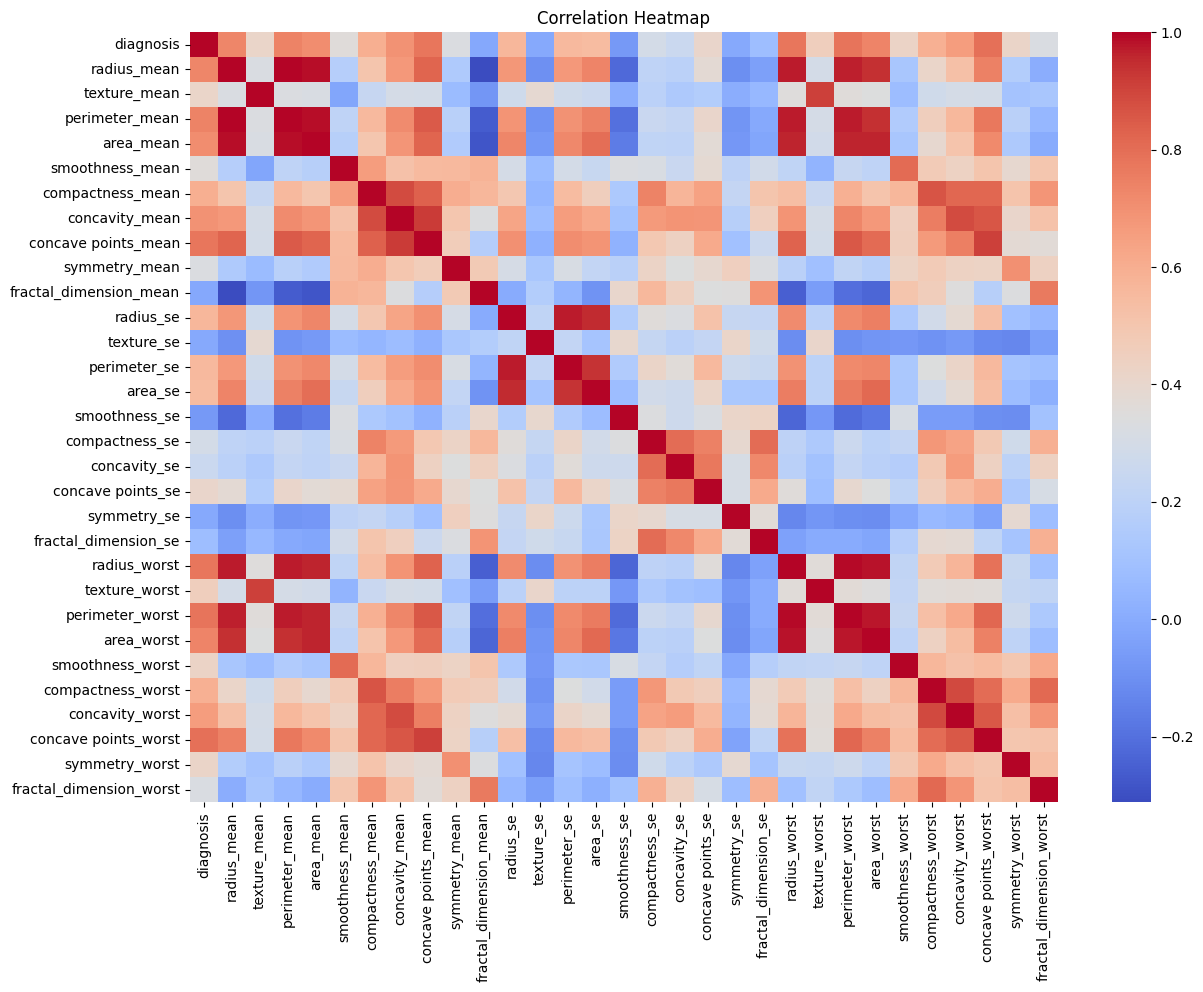

In [26]:
# Heatmap

plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


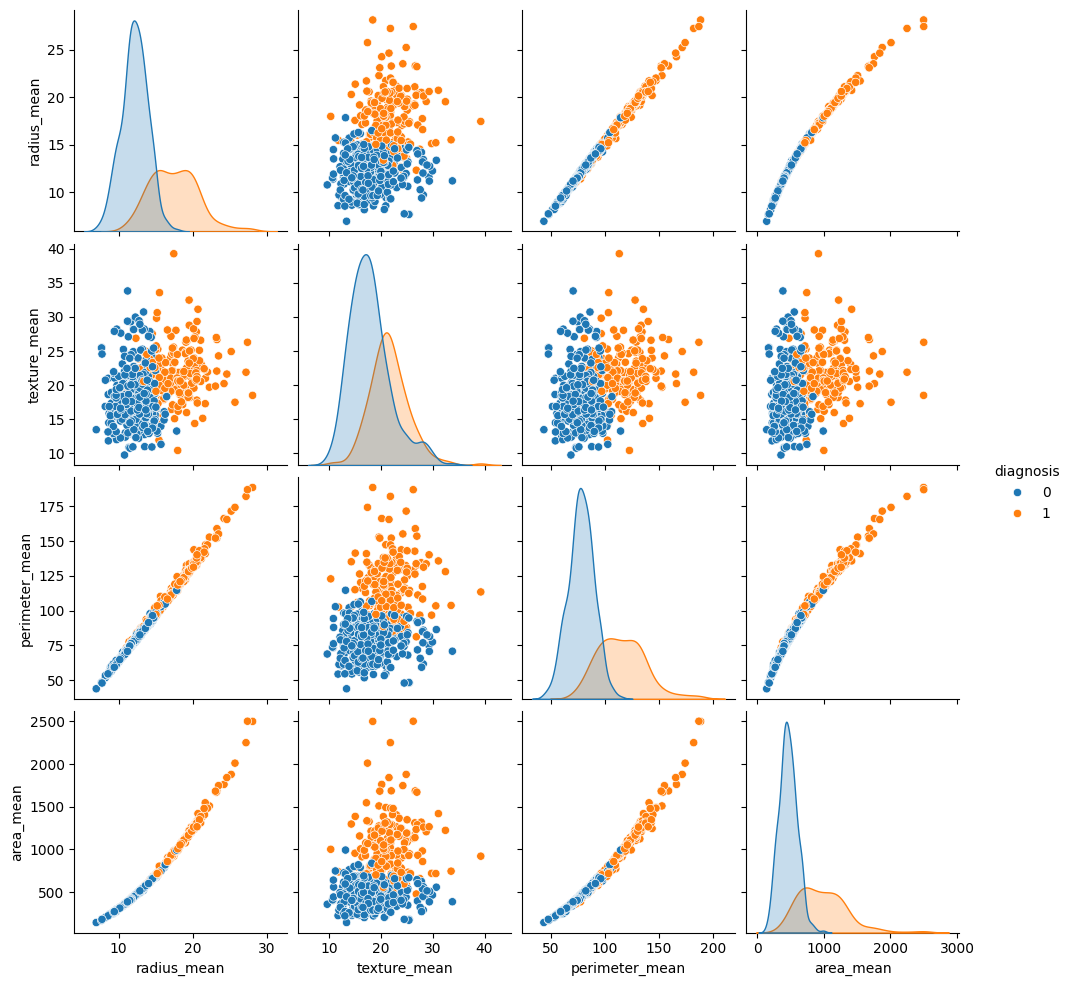

In [27]:
# Pairplot

sns.pairplot(
    df[[
        "radius_mean",
        "texture_mean",
        "perimeter_mean",
        "area_mean",
        "diagnosis"
    ]],
    hue="diagnosis"
)
plt.show()

In [28]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [30]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
y_pred = model.predict(X_test)


In [32]:
print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))



Accuracy:
0.9736842105263158


In [33]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [34]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[72  0]
 [ 3 39]]
